In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, davies_bouldin_score
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [148]:
df=pd.read_csv('customer_segmentation.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [149]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [151]:
df['Income'].fillna(df['Income'].mean(), inplace=True)

In [152]:
df.duplicated().sum()

np.int64(0)

In [153]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Customer_For"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days

In [154]:
print("Total categories in Maritial_Status:") 
print(df['Marital_Status'].value_counts())

print("Total categories in Education_Level:")
print(df['Education'].value_counts())

Total categories in Maritial_Status:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
Total categories in Education_Level:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [155]:
# Education Simplification
df["Education"] = df["Education"].replace({
    "Basic": "UnderGraduate",
    "2n Cycle": "UnderGraduate",
    "Graduation": "Graduate",
    "Master": "PostGraduate",
    "PhD": "PostGraduate"
})

# Marital Status to Living_With
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Married_partner",
    "Together": "Partner",
    "Absurd": "Alone",
    "Widow": "Alone",
    "YOLO": "Alone",
    "Divorced": "Alone",
    "Single": "Alone"
})

In [156]:
df['Age']=2025-df['Year_Birth']

In [157]:
# Spending Total
df["Spent"] = df[["MntWines", "MntFruits", "MntMeatProducts",
                  "MntFishProducts", "MntSweetProducts", "MntGoldProds"]].sum(axis=1)

In [158]:
# Children and Family Size
df["Children"] = df["Kidhome"] + df["Teenhome"]

In [159]:
df["Family_Size"] = df["Children"] + df["Living_With"].replace({"Alone": 1, "Partner": 2, "Married_partner": 2})
df["Is_Parent"] = np.where(df["Children"] > 0, 1, 0)

In [160]:
df=df.rename(columns={
    "MntWines": "Wine_Spent",
    "MntFruits": "Fruit_Spent",
    "MntMeatProducts": "Meat_Spent",
    "MntFishProducts": "Fish_Spent",
    "MntSweetProducts": "Sweet_Spent",
    "MntGoldProds": "Gold_Spent",
})

In [161]:
to_drop=['Kidhome','Teenhome','ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue','Marital_Status']
df=df.drop(to_drop, axis=1)

In [162]:
df.head()

,Education,Income,Recency,Wine_Spent,Fruit_Spent,Meat_Spent,Fish_Spent,Sweet_Spent,Gold_Spent,NumDealsPurchases,...,AcceptedCmp2,Complain,Response,Customer_For,Living_With,Age,Spent,Children,Family_Size,Is_Parent
0,Graduate,58138.0,58,635,88,546,172,88,88,3,...,0,0,1,663,Alone,68,1617,0,1,0
1,Graduate,46344.0,38,11,1,6,2,1,6,2,...,0,0,0,113,Alone,71,27,2,3,1
2,Graduate,71613.0,26,426,49,127,111,21,42,1,...,0,0,0,312,Partner,60,776,0,2,0
3,Graduate,26646.0,26,11,4,20,10,3,5,2,...,0,0,0,139,Partner,41,53,1,3,1
4,PostGraduate,58293.0,94,173,43,118,46,27,15,5,...,0,0,0,161,Married_partner,44,422,1,3,1


In [163]:
df = df[(df["Age"]<90)]
df = df[(df["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(df))

The total number of data-points after removing the outliers are: 2236


In [164]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [165]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])


In [166]:
from sklearn.pipeline import Pipeline
preprocessing_pca_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('pca', PCA(n_components=12))  # keep 90% variance
])


In [167]:
pca_data = preprocessing_pca_pipeline.fit_transform(df)
print("PCA data shape:", pca_data.shape)


PCA data shape: (2236, 12)


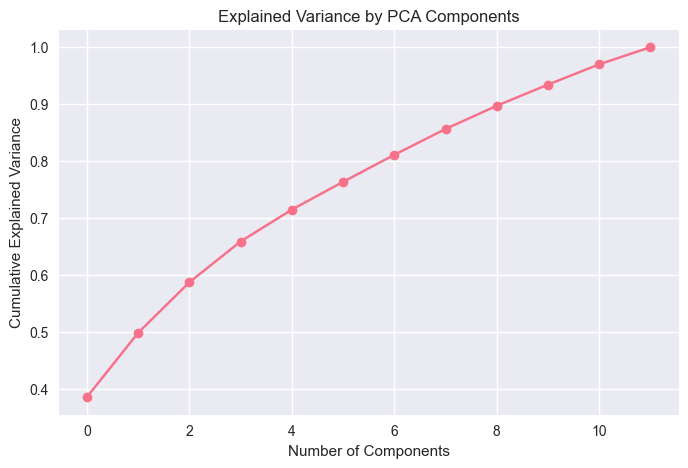

In [168]:
# PCA with no fixed components to check explained variance
pca = PCA()
pca.fit(pca_data)

# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()


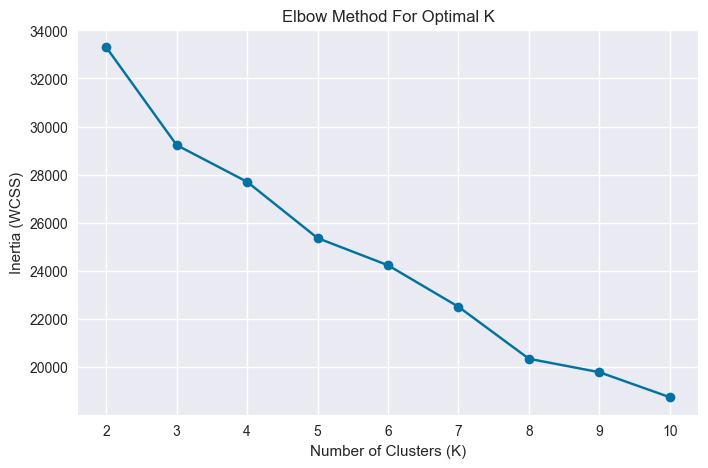

In [169]:
# Finding optimal number of clusters using Elbow method
inertia = []
K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    model.fit(pca_data)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()


In [170]:
# Task 1: K-Means Clustering
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(pca_data)

# Evaluation metrics
kmeans_silhouette = silhouette_score(pca_data, df['KMeans_Cluster'])
kmeans_davies = davies_bouldin_score(pca_data, df['KMeans_Cluster'])

print("K-Means Clustering Results:")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Score: {kmeans_davies:.4f}")
print("\nCluster Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())


K-Means Clustering Results:
Silhouette Score: 0.2393
Davies-Bouldin Score: 1.6724

Cluster Distribution:
KMeans_Cluster
0    1107
1     508
2     621
Name: count, dtype: int64


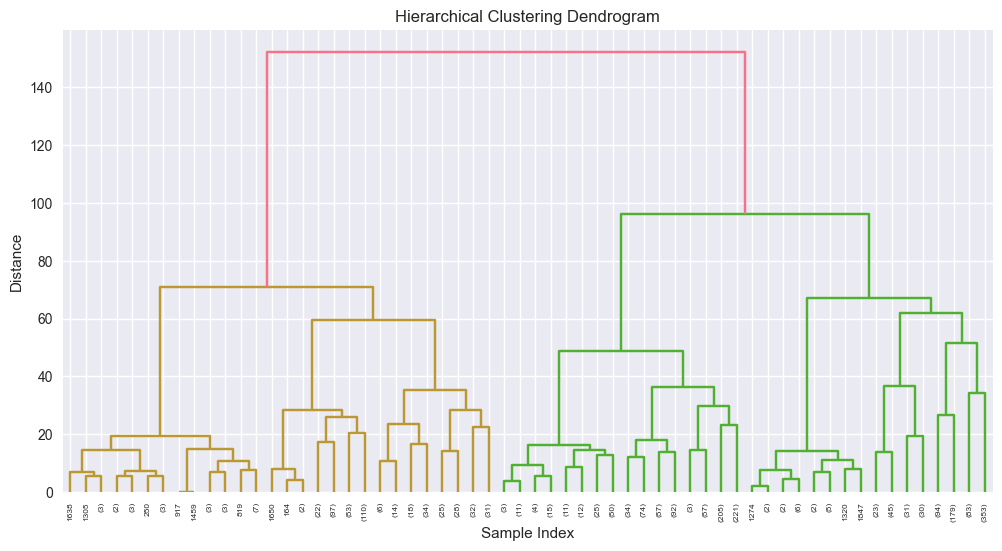

Hierarchical Clustering Results:
Silhouette Score: 0.1869
Davies-Bouldin Score: 1.8174

Cluster Distribution:
Agglo_Cluster
0    504
1    858
2    874
Name: count, dtype: int64


In [171]:
# Task 2: Hierarchical Clustering
# Creating dendrogram
linkage_matrix = linkage(pca_data, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Applying Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Agglo_Cluster'] = agglo.fit_predict(pca_data)

# Evaluation metrics
agglo_silhouette = silhouette_score(pca_data, df['Agglo_Cluster'])
agglo_davies = davies_bouldin_score(pca_data, df['Agglo_Cluster'])

print("Hierarchical Clustering Results:")
print(f"Silhouette Score: {agglo_silhouette:.4f}")
print(f"Davies-Bouldin Score: {agglo_davies:.4f}")
print("\nCluster Distribution:")
print(df['Agglo_Cluster'].value_counts().sort_index())


In [172]:
df.head(10)

,Education,Income,Recency,Wine_Spent,Fruit_Spent,Meat_Spent,Fish_Spent,Sweet_Spent,Gold_Spent,NumDealsPurchases,...,Response,Customer_For,Living_With,Age,Spent,Children,Family_Size,Is_Parent,KMeans_Cluster,Agglo_Cluster
0,Graduate,58138.0,58,635,88,546,172,88,88,3,...,1,663,Alone,68,1617,0,1,0,1,0
1,Graduate,46344.0,38,11,1,6,2,1,6,2,...,0,113,Alone,71,27,2,3,1,0,2
2,Graduate,71613.0,26,426,49,127,111,21,42,1,...,0,312,Partner,60,776,0,2,0,1,0
3,Graduate,26646.0,26,11,4,20,10,3,5,2,...,0,139,Partner,41,53,1,3,1,0,2
4,PostGraduate,58293.0,94,173,43,118,46,27,15,5,...,0,161,Married_partner,44,422,1,3,1,2,1
5,PostGraduate,62513.0,16,520,42,98,0,42,14,2,...,0,293,Partner,58,716,1,3,1,2,1
6,Graduate,55635.0,34,235,65,164,50,49,27,4,...,0,593,Alone,54,590,1,2,1,2,1
7,PostGraduate,33454.0,32,76,10,56,3,1,23,2,...,0,417,Married_partner,40,169,1,3,1,0,2
8,PostGraduate,30351.0,19,14,0,24,3,3,2,1,...,1,388,Partner,51,46,1,3,1,0,2
9,PostGraduate,5648.0,68,28,0,6,1,1,13,1,...,0,108,Partner,75,49,2,4,1,0,1


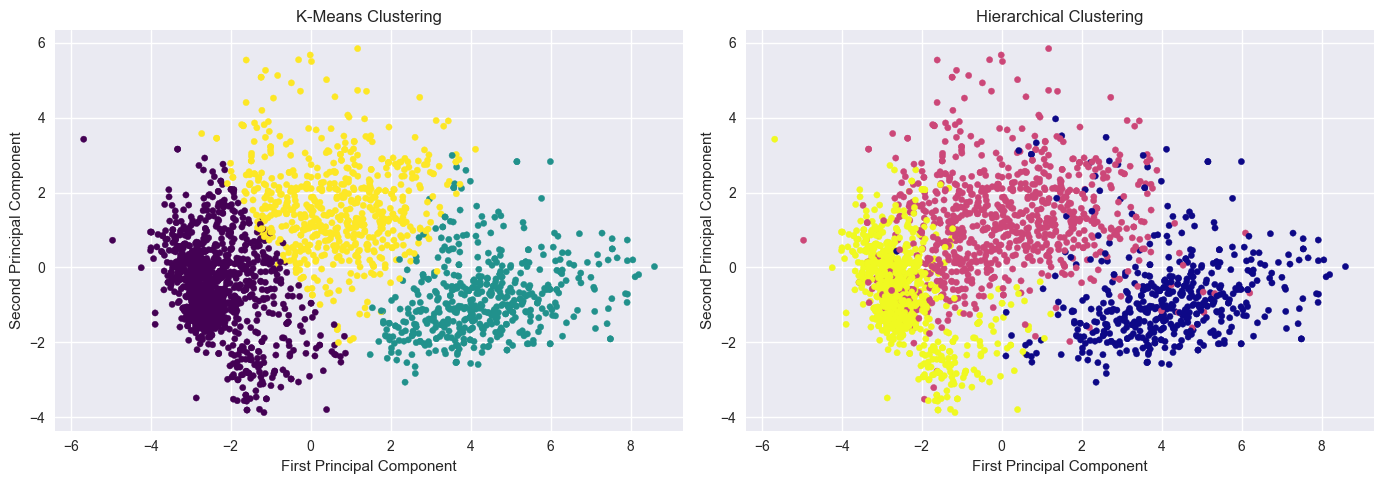

In [173]:
# Visualizing clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pca_data[:, 0], pca_data[:, 1], c=df['KMeans_Cluster'], cmap='viridis', s=20)
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].set_title('K-Means Clustering')
axes[0].grid(True)

axes[1].scatter(pca_data[:, 0], pca_data[:, 1], c=df['Agglo_Cluster'], cmap='plasma', s=20)
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')
axes[1].set_title('Hierarchical Clustering')
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [174]:
# Cluster profile analysis - K-Means
key_features = ['Income', 'Age', 'Spent', 'Recency', 'NumWebPurchases', 'NumStorePurchases']
kmeans_profiles = df.groupby('KMeans_Cluster')[key_features].mean()
print("K-Means Cluster Profiles:")
print(kmeans_profiles.round(2))


K-Means Cluster Profiles:
                  Income    Age    Spent  Recency  NumWebPurchases  \
KMeans_Cluster                                                       
0               36037.49  54.06   110.64    49.04             2.25   
1               76825.43  56.51  1415.63    49.38             4.94   
2               60009.68  59.40   826.69    49.04             6.67   

                NumStorePurchases  
KMeans_Cluster                     
0                            3.36  
1                            8.27  
2                            8.12  


In [175]:
# Cluster profile analysis - Hierarchical
agglo_profiles = df.groupby('Agglo_Cluster')[key_features].mean()
print("Hierarchical Cluster Profiles:")
print(agglo_profiles.round(2))


Hierarchical Cluster Profiles:
                 Income    Age    Spent  Recency  NumWebPurchases  \
Agglo_Cluster                                                       
0              75817.43  56.86  1376.75    50.09             4.87   
1              56733.30  58.42   682.11    48.22             5.74   
2              33521.36  53.39    86.79    49.44             2.01   

               NumStorePurchases  
Agglo_Cluster                     
0                           8.24  
1                           7.06  
2                           3.15  


Algorithm Comparison:
              Metric  K-Means  Hierarchical
    Silhouette Score 0.239250      0.186931
Davies-Bouldin Score 1.672382      1.817393



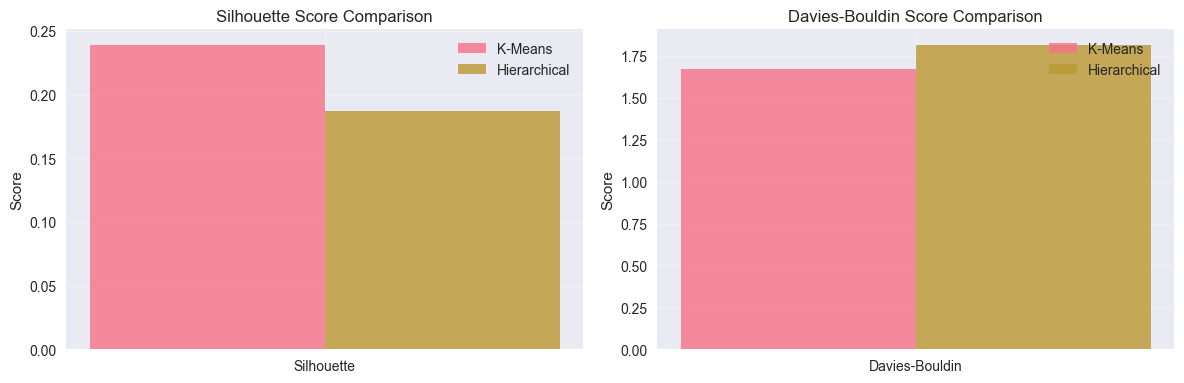

In [176]:
# Task 3: Comparison of Clusters
comparison_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Score'],
    'K-Means': [kmeans_silhouette, kmeans_davies],
    'Hierarchical': [agglo_silhouette, agglo_davies]
})

print("Algorithm Comparison:")
print(comparison_df.to_string(index=False))
print()

# Simple comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

width = 0.35
x = [0]

# Silhouette Score comparison
axes[0].bar([x[0] - width/2], [kmeans_silhouette], width, label='K-Means', alpha=0.8)
axes[0].bar([x[0] + width/2], [agglo_silhouette], width, label='Hierarchical', alpha=0.8)
axes[0].set_ylabel('Score')
axes[0].set_title('Silhouette Score Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Silhouette'])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Davies-Bouldin Score comparison
axes[1].bar([x[0] - width/2], [kmeans_davies], width, label='K-Means', alpha=0.8)
axes[1].bar([x[0] + width/2], [agglo_davies], width, label='Hierarchical', alpha=0.8)
axes[1].set_ylabel('Score')
axes[1].set_title('Davies-Bouldin Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Davies-Bouldin'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Conclusion:
- here, both algorithms successfully identified 3 distinct customer segments.
- K-means shows slightly better cluster separation based on evaluation scores.